# 实验 19: 进阶 CNN —— 基于 DenseNet 的 CIFAR-10 图像分类

**课程**: 深度学习进阶 / 计算机视觉   

## 1. 实验目标
1.  **理论掌握**：理解 **DenseNet (密集连接卷积网络)** 的核心思想（特征复用、拼接连接）及其与 ResNet 的区别。
2.  **编程实践**：掌握 PyTorch 中高阶模型的搭建技巧，特别是 `torch.cat` 维度拼接操作。
3.  **工程能力**：学会处理 **CIFAR-10** 彩色数据集，使用数据增强（Data Augmentation）防止过拟合，并可视化训练过程。

---

## 2. 知识点与背景

### 什么是 DenseNet？
随着网络越来越深，梯度消失问题变得严峻。ResNet 通过“相加” ($y = x + f(x)$) 解决了这个问题。而 DenseNet 提出了更激进的思路：**“每一层都直接连接到后面所有层”**。

### 核心公式
$$x_l = H_l([x_0, x_1, ..., x_{l-1}])$$
其中 $[...]$ 表示在**通道维度上的拼接 (Concatenation)**。这意味着第 $l$ 层能够直接“看见”之前所有层的特征图。这种机制极大地促进了**特征复用**，使得网络可以用更少的参数达到极高的准确率。

### 为什么要设计“简化版”？
标准的 DenseNet-121 是为 ImageNet (224x224) 设计的。CIFAR-10 只有 32x32，如果直接用原版模型，特征图会过早变得太小。本实验我们将手动搭建一个**适配 32x32 输入的 Mini-DenseNet**。

In [9]:
# 1. 导入必要的库
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import os
import math

# 检查 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前使用的计算设备: {device}")

当前使用的计算设备: cuda


## 3. 数据加载与增强 (Data Augmentation)

CIFAR-10 包含 50,000 张训练图，很容易过拟合。我们必须引入**数据增强**。
- **RandomCrop**: 随机裁剪（先填充 4 像素，再切回 32x32），让物体位置微调。
- **RandomHorizontalFlip**: 随机左右翻转（猫头朝左还是朝右都是猫）。
- **Normalize**: CIFAR-10 的 RGB 三通道均值和方差分别是 `(0.4914, 0.4822, 0.4465)` 和 `(0.2023, 0.1994, 0.2010)`。

In [2]:
# 定义数据增强与预处理
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# 定义数据路径
data_path = '../data'
if not os.path.exists(data_path):
    os.makedirs(data_path)

print("正在加载 CIFAR-10 数据集 (首次运行会自动下载)...")
train_set = torchvision.datasets.CIFAR10(root=data_path, train=True, download=True, transform=train_transform)
test_set = torchvision.datasets.CIFAR10(root=data_path, train=False, download=True, transform=test_transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=100, shuffle=False, num_workers=2)

classes = ('Plane', 'Car', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck')
print(f"训练集大小: {len(train_set)}, 测试集大小: {len(test_set)}")

正在加载 CIFAR-10 数据集 (首次运行会自动下载)...


100.0%


Extracting ../data\cifar-10-python.tar.gz to ../data
Files already downloaded and verified
训练集大小: 50000, 测试集大小: 10000


### 3.1 查看数据
眼见为实。我们要看看经过“反归一化”后的图片长什么样。
注意：CIFAR-10 图片很模糊（32x32），这是正常的。

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..1.0].


随机展示 4 张训练图片:


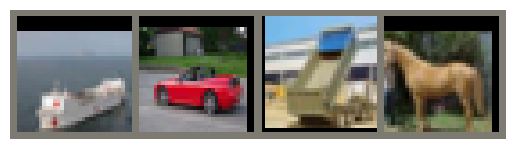

Ship  Car   Truck Horse


In [3]:
def imshow(img):
    # 反归一化: img = (img * std) + mean
    img = img * torch.tensor([0.2023, 0.1994, 0.2010]).view(3,1,1) + torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# 随机获取一些图片
dataiter = iter(train_loader)
images, labels = next(dataiter)

print("随机展示 4 张训练图片:")
imshow(torchvision.utils.make_grid(images[:4]))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

## 4. 搭建 DenseNet 模型 (核心部分)

DenseNet 由三个基本组件构成：
1.  **Bottleneck Layer**: `BN -> ReLU -> Conv(1x1) -> BN -> ReLU -> Conv(3x3)`。这是最小的卷积单元。
2.  **Transition Layer (过渡层)**: 放在两个 Block 之间，用于把通道数减半，把长宽减半。
3.  **DenseBlock (密集块)**: 包含多个 Bottleneck Layer，每层的输出都会拼接到输入后面。

In [12]:
class Bottleneck(nn.Module):
    def __init__(self, in_planes, growth_rate):
        super(Bottleneck, self).__init__()
        self.bn1 = nn.BatchNorm2d(in_planes)
        self.conv1 = nn.Conv2d(in_planes, 4*growth_rate, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(4*growth_rate)
        self.conv2 = nn.Conv2d(4*growth_rate, growth_rate, kernel_size=3, padding=1, bias=False)

    def forward(self, x):
        out = self.conv1(torch.relu(self.bn1(x)))
        out = self.conv2(torch.relu(self.bn2(out)))
        # 【核心操作】将输入 x 和输出 out 在通道维度 (dim=1) 进行拼接
        return torch.cat([out, x], 1)

class Transition(nn.Module):
    def __init__(self, in_planes, out_planes):
        super(Transition, self).__init__()
        self.bn = nn.BatchNorm2d(in_planes)
        self.conv = nn.Conv2d(in_planes, out_planes, kernel_size=1, bias=False)

    def forward(self, x):
        out = self.conv(torch.relu(self.bn(x)))
        # 使用平均池化把尺寸减半 (32->16, 16->8)
        out = F.avg_pool2d(out, 2)
        return out

class DenseNet(nn.Module):
    def __init__(self, block, nblocks, growth_rate=12, reduction=0.5, num_classes=10):
        super(DenseNet, self).__init__()
        self.growth_rate = growth_rate

        # 1. 初始卷积层 (把 3通道 变成 2*growth_rate 通道)
        num_planes = 2 * growth_rate
        self.conv1 = nn.Conv2d(3, num_planes, kernel_size=3, padding=1, bias=False)

        # 2. 搭建 3 个 DenseBlock
        self.dense1 = self._make_dense_layers(block, num_planes, nblocks[0])
        num_planes += nblocks[0] * growth_rate
        # Transition 1
        out_planes = int(math.floor(num_planes * reduction))
        self.trans1 = Transition(num_planes, out_planes)
        num_planes = out_planes

        self.dense2 = self._make_dense_layers(block, num_planes, nblocks[1])
        num_planes += nblocks[1] * growth_rate
        # Transition 2
        out_planes = int(math.floor(num_planes * reduction))
        self.trans2 = Transition(num_planes, out_planes)
        num_planes = out_planes

        self.dense3 = self._make_dense_layers(block, num_planes, nblocks[2])
        num_planes += nblocks[2] * growth_rate

        # 3. 分类层
        self.bn = nn.BatchNorm2d(num_planes)
        self.linear = nn.Linear(num_planes, num_classes)

    def _make_dense_layers(self, block, in_planes, nblock):
        layers = []
        for i in range(nblock):
            layers.append(block(in_planes, self.growth_rate))
            in_planes += self.growth_rate
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv1(x)
        out = self.trans1(self.dense1(out))
        out = self.trans2(self.dense2(out))
        out = self.dense3(out)
        # 应用 Batch Normalization 和 ReLU
        out = torch.relu(self.bn(out))
        # 全局平均池化：把所有空间维度池化为 1x1
        out = F.adaptive_avg_pool2d(out, (1, 1))
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out

# 实例化一个 Mini-DenseNet
# nblocks=[2, 4, 4] 表示三个 Block 分别有 2, 4, 4 层，这是一个非常小的网络，适合教学
model = DenseNet(Bottleneck, [2, 4, 4], growth_rate=12).to(device)

# 打印参数量
total_params = sum(p.numel() for p in model.parameters())
print(f"模型构建成功！总参数量: {total_params:,}")

模型构建成功！总参数量: 80,650


## 5. 训练模型

CIFAR-10 数据量要大一些。即使是这个简化版模型，也需要跑 10-20 个 Epoch 才能看到不错的效果。
为了节省课堂时间，我们先跑 **15 个 Epoch**。

In [13]:
criterion = nn.CrossEntropyLoss()
# 使用 SGD + Momentum，这是训练 CNN 的标准配置
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
# 学习率衰减: 每 5 个 epoch 把学习率乘 0.1
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

epochs = 15
history = {'train_loss': [], 'test_acc': []}

print(f"开始训练 (总轮数: {epochs})...")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    scheduler.step()
    train_loss = running_loss / len(train_loader)
    train_acc = 100. * correct / total
    history['train_loss'].append(train_loss)

    # --- 验证 ---
    model.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()
    
    test_acc = 100. * test_correct / test_total
    history['test_acc'].append(test_acc)

    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

print("训练完成！")

开始训练 (总轮数: 15)...
Epoch [1/15] | Loss: 1.5640 | Train Acc: 41.13% | Test Acc: 51.20%
Epoch [2/15] | Loss: 1.1116 | Train Acc: 59.81% | Test Acc: 54.43%
Epoch [3/15] | Loss: 0.9611 | Train Acc: 65.54% | Test Acc: 63.35%
Epoch [4/15] | Loss: 0.8884 | Train Acc: 68.66% | Test Acc: 61.32%
Epoch [5/15] | Loss: 0.8272 | Train Acc: 70.84% | Test Acc: 66.44%
Epoch [6/15] | Loss: 0.6552 | Train Acc: 77.08% | Test Acc: 77.64%
Epoch [7/15] | Loss: 0.6079 | Train Acc: 78.82% | Test Acc: 77.55%
Epoch [8/15] | Loss: 0.5886 | Train Acc: 79.37% | Test Acc: 78.21%
Epoch [9/15] | Loss: 0.5706 | Train Acc: 79.91% | Test Acc: 78.97%
Epoch [10/15] | Loss: 0.5556 | Train Acc: 80.59% | Test Acc: 78.23%
Epoch [11/15] | Loss: 0.5167 | Train Acc: 81.98% | Test Acc: 81.04%
Epoch [12/15] | Loss: 0.5071 | Train Acc: 82.35% | Test Acc: 80.89%
Epoch [13/15] | Loss: 0.5001 | Train Acc: 82.67% | Test Acc: 81.18%
Epoch [14/15] | Loss: 0.5005 | Train Acc: 82.67% | Test Acc: 81.15%
Epoch [15/15] | Loss: 0.4956 | Train Ac

## 6. 结果可视化与评估

训练只是第一步。我们需要通过可视化来确认模型是真的学会了，还是只是死记硬背（过拟合）。

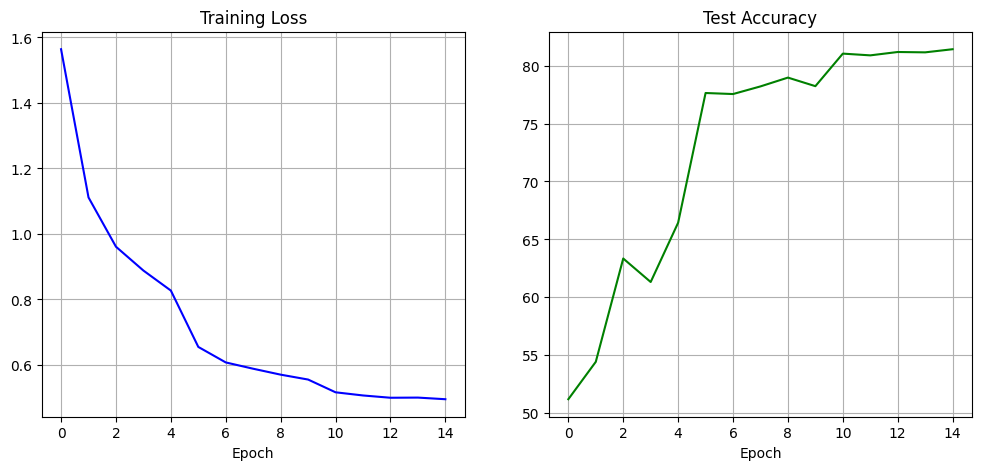

In [16]:
# 1. 绘制训练曲线
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history['test_acc'], label='Test Accuracy', color='green')
plt.title('Test Accuracy')
plt.xlabel('Epoch')
plt.grid()
plt.show()

### 6.1 混淆矩阵热力图
在 MNIST 里我们很容易分清 0 和 1。但在 CIFAR-10 里，**猫和狗**、**汽车和卡车**是重灾区。
我们用热力图来看看模型最容易把什么认错。

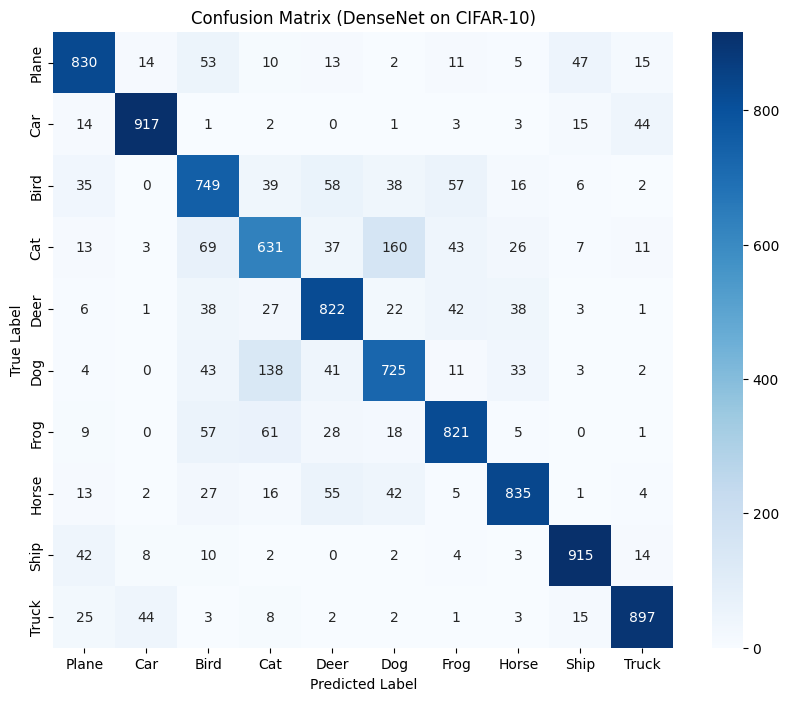

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix (DenseNet on CIFAR-10)')
plt.show()

### 6.2 各类别准确率排行
混淆矩阵虽然全，但有时候看花眼。这个柱状图能一目了然：“哪个类别难认？哪个类别简单？”

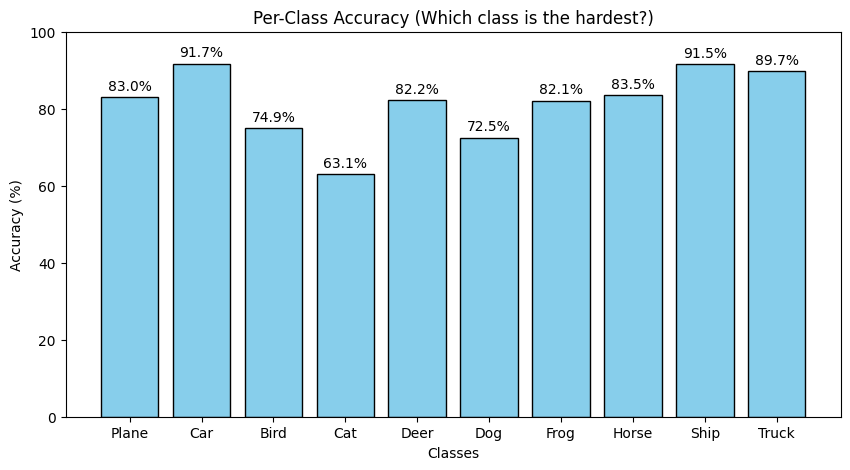

In [18]:
# 计算每个类别的准确率
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()
        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

# 绘图
class_acc = [100 * class_correct[i] / class_total[i] for i in range(10)]

plt.figure(figsize=(10, 5))
bars = plt.bar(classes, class_acc, color='skyblue', edgecolor='black')
plt.xlabel('Classes')
plt.ylabel('Accuracy (%)')
plt.title('Per-Class Accuracy (Which class is the hardest?)')
plt.ylim(0, 100)

# 在柱子上标数值
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom')

plt.show()

### 6.3 第一层卷积核特征图可视化
通过可视化第一层卷积的输出，可以看到模型提取了边缘、颜色、纹理。这比看枯燥的数字矩阵直观得多。

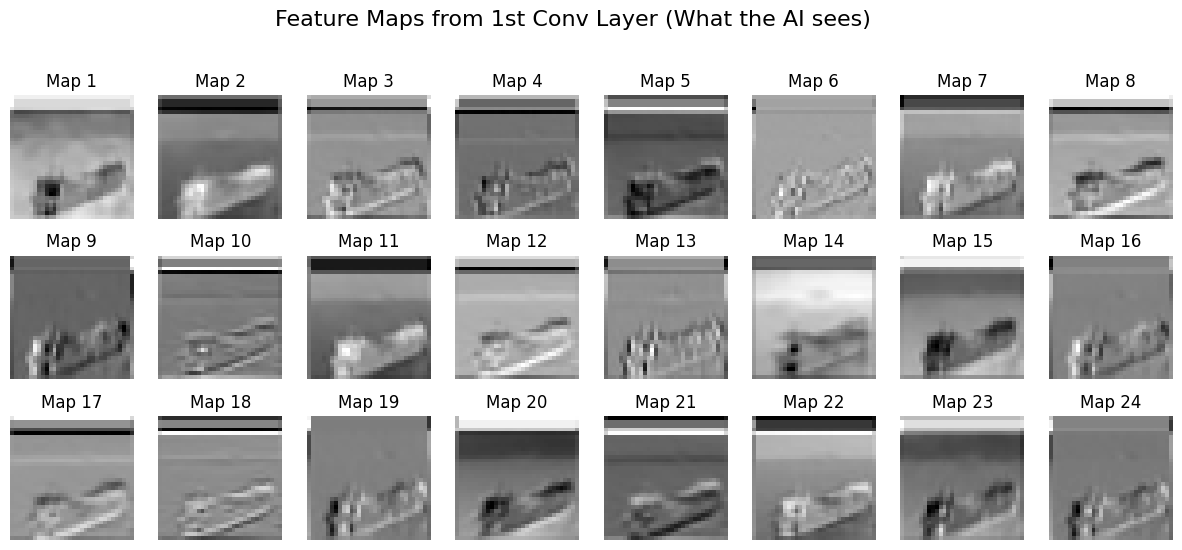

In [19]:
def visualize_first_layer_features(model, image):
    model.eval()
    with torch.no_grad():
        # 获取第一层卷积的输出
        # DenseNet 的第一层通常叫 conv1
        img_tensor = image.unsqueeze(0).to(device)
        feature_maps = model.conv1(img_tensor) 
        
        # feature_maps 形状应该是 [1, 24, 32, 32]
        
    feature_maps = feature_maps.squeeze().cpu().numpy()
    num_maps = feature_maps.shape[0]
    
    # 绘图：画成网格状
    plt.figure(figsize=(15, 8))
    columns = 8
    rows = num_maps // columns + 1
    
    for i in range(num_maps):
        plt.subplot(rows, columns, i+1)
        plt.imshow(feature_maps[i], cmap='gray') # 特征图是单通道的，用灰度显示
        plt.axis('off')
        plt.title(f'Map {i+1}')
    
    plt.suptitle(f"Feature Maps from 1st Conv Layer (What the AI sees)", fontsize=16)
    plt.show()

# 使用示例：看看第一张测试图在网络眼里长什么样
visualize_first_layer_features(model, images[0])

### 6.4 交互式预测演示
点一点按钮，随机抽取测试集图片，看看 AI 猜对了没。

Button(button_style='info', description='🎲 换一批预测', icon='refresh', style=ButtonStyle())

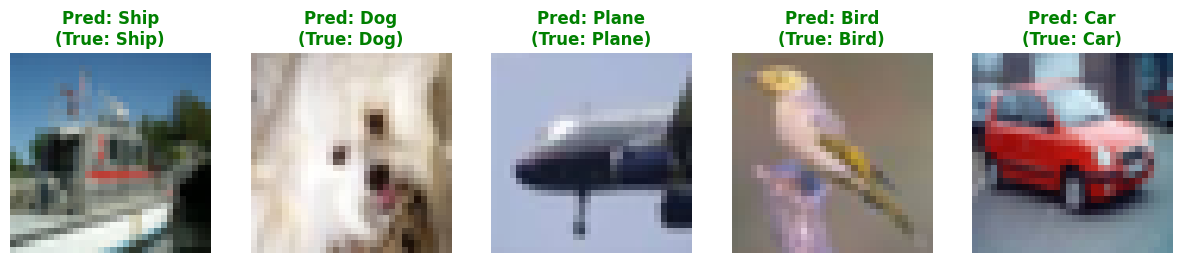

In [20]:
import ipywidgets as widgets
from IPython.display import display, clear_output

test_iter = iter(test_loader)

def on_button_click(b):
    global test_iter
    try:
        images, labels = next(test_iter)
    except StopIteration:
        test_iter = iter(test_loader)
        images, labels = next(test_iter)
    
    clear_output(wait=True)
    display(button)
    
    images = images.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)
    
    plt.figure(figsize=(15, 3))
    for i in range(5):
        plt.subplot(1, 5, i+1)
        # 反归一化
        img_show = images[i].cpu() * torch.tensor([0.2023, 0.1994, 0.2010]).view(3,1,1) + torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
        img_show = np.clip(img_show.numpy(), 0, 1)
        plt.imshow(np.transpose(img_show, (1, 2, 0)))
        
        title_color = 'green' if predicted[i] == labels[i] else 'red'
        plt.title(f"Pred: {classes[predicted[i]]}\n(True: {classes[labels[i]]})", 
                  color=title_color, fontweight='bold')
        plt.axis('off')
    plt.show()

button = widgets.Button(description=' 换一批预测', button_style='info', icon='refresh')
button.on_click(on_button_click)
on_button_click(None)

## 7. 拓展与思考 (Discussion)

### 🤔 思考题
1.  **参数效率对比**：
    我们搭建的这个 DenseNet，总参数量非常少（大概几十万），但可能比几百万参数的普通 CNN 效果还好。为什么“密集连接”能这么省参数？
    
2.  **1x1 卷积的作用**：
    在 `Bottleneck` 类中，我们先用了一个 `1x1` 卷积，再接 `3x3` 卷积。如果不加这个 `1x1` 卷积，计算量会发生什么变化？（提示：这叫 Bottleneck Layer，瓶颈层）。
    
3.  **Global Average Pooling**：
    在最后，我们用全局平均池化层把 4x4 的特征图变成了 1x1。相比于直接把 4x4 展平（Flatten），这样做有什么好处？

---

### 💡 解答思路

<details>
<summary><strong>点击查看解答</strong></summary>

#### 1. 参数效率
DenseNet 的每一层都很窄（Growth Rate 只有 12），它靠的是**拼接待**（Concatenation）来复用之前的特征。这就像写代码时“调用函数”而不是“复制粘贴代码”，复用率极高，所以参数少。

#### 2. 1x1 卷积 (Bottleneck)
DenseNet 的输入通道数会变得非常大（比如 256）。如果直接用 3x3 卷积去卷 256 个通道，计算量是爆炸的。1x1 卷积的作用是**先降维**（比如把 256 降到 48），然后再用 3x3 卷积，这样能把计算量降低几倍甚至几十倍。

#### 3. Global Avg Pooling
直接展平会保留空间信息，导致全连接层参数巨大，且容易过拟合。全局平均池化强行丢弃了空间位置信息（只关心“有没有猫”，不关心“猫在哪”），大大减少了参数量，且能防止过拟合。

</details>